In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, SubsetRandomSampler
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils import resample
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [2]:
# PyTorch Dataset
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # Add channel dimension
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [ ]:
# Load data
current_dir = os.getcwd()
path_train = current_dir + "/../dataset/mitbih/" + "mitbih_train.csv"
path_test = current_dir + "/../dataset/mitbih/" + "mitbih_test.csv"

df_train = pd.read_csv(path_train, header=None)
df_test = pd.read_csv(path_test, header=None)

df_train.rename(columns={187:"Class"}, inplace=True)
df_test.rename(columns={187:"Class"}, inplace=True)

print("Dataset after resample")
print("Training set")
print(df_train.shape)
print(df_train["Class"].value_counts())
print("Testing set")
print(df_test.shape)
print(df_test["Class"].value_counts())
#extract class
class_0=df_train[df_train["Class"]==0]
class_1=df_train[df_train["Class"]==1]
class_2=df_train[df_train["Class"]==2]
class_3=df_train[df_train["Class"]==3]
class_4=df_train[df_train["Class"]==4]

class_0_upsample=resample(class_0,replace=True,n_samples=80000,random_state=123)
class_1_upsample=resample(class_1,replace=True,n_samples=10000,random_state=123)
class_2_upsample=resample(class_2,replace=True,n_samples=10000,random_state=124)
class_3_upsample=resample(class_3,replace=True,n_samples=10000,random_state=125)
class_4_upsample=resample(class_4,replace=True,n_samples=10000,random_state=126)

#combine
df_train=pd.concat([class_0_upsample,class_1_upsample,class_2_upsample,class_3_upsample,class_4_upsample])
print("Dataset after resample")
print(df_train.shape)
print(df_train["Class"].value_counts())

# Drop any non-numeric column (like 'Class' from the header row)
df_train = df_train.apply(pd.to_numeric, errors='coerce')
df_test = df_test.apply(pd.to_numeric, errors='coerce')

# Remove any NaN values (in case 'Class' was still causing issues)
#df_train = df_train.dropna()
#df_test = df_test.dropna()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Split features and labels
X_train, y_train = df_train.iloc[:, :-1].values, df_train.iloc[:, -1].values
X_test, y_test = df_test.iloc[:, :-1].values, df_test.iloc[:, -1].values

reduction_factor = 0.25  # Keep 25% of the dataset

# Dataloaders
train_valid_dataset = ECGDataset(X_train, y_train)
test_dataset = ECGDataset(X_test, y_test)

batch_size = 32
train_size = int(0.8 * len(train_valid_dataset))
val_size = len(train_valid_dataset) - train_size
train_dataset, val_dataset = random_split(train_valid_dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Dataset after resample
Training set
(87554, 188)
Class
0.0    72471
4.0     6431
2.0     5788
1.0     2223
3.0      641
Name: count, dtype: int64
Testing set
(21892, 188)
Class
0.0    18118
4.0     1608
2.0     1448
1.0      556
3.0      162
Name: count, dtype: int64
Dataset after resample
(90000, 188)
Class
0.0    50000
1.0    10000
2.0    10000
3.0    10000
4.0    10000
Name: count, dtype: int64


In [4]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class RCNN(nn.Module):
    def __init__(self, input_size=187, num_classes=5):
        super(RCNN, self).__init__()

        # Define Convolution Layers
        self.conv1_1 = nn.Conv1d(in_channels=1, out_channels=48, kernel_size=6, padding='same')
        self.bn1_1 = nn.BatchNorm1d(48)

        self.conv1_2 = nn.Conv1d(48, 64, 6, padding='same')
        self.bn1_2 = nn.BatchNorm1d(64)
        
        self.conv1_3 = nn.Conv1d(64, 32, 6, padding='same')
        self.bn1_3 = nn.BatchNorm1d(32)

        self.residual_1 = nn.Conv1d(32, 16, 16, padding='same')
        self.bn_residual_1 = nn.BatchNorm1d(16)
        
        self.conv1_4 = nn.Conv1d(48, 64, 6, padding='same')
        self.bn1_4 = nn.BatchNorm1d(64)

        self.conv1_5 = nn.Conv1d(64, 32, 6, padding='same')
        self.bn1_5 = nn.BatchNorm1d(32)

        self.residual_2 = nn.Conv1d(32, 16, 16, padding='same')
        self.bn_residual_2 = nn.BatchNorm1d(16)
        
        self.conv1_6 = nn.Conv1d(48, 64, 6, padding='same')
        self.bn1_6 = nn.BatchNorm1d(64)

        self.conv1_7 = nn.Conv1d(64, 32, 6, padding='same')
        self.bn1_7 = nn.BatchNorm1d(32)

        self.residual_3 = nn.Conv1d(32, 16, 16, padding='same')
        self.bn_residual_3 = nn.BatchNorm1d(16)
        
        self.conv1_8 = nn.Conv1d(48, 64, 6, padding='same')
        self.bn1_8 = nn.BatchNorm1d(64)

        self.conv1_9 = nn.Conv1d(64, 32, 6, padding='same')
        self.bn1_9 = nn.BatchNorm1d(32)

        self.residual_4 = nn.Conv1d(32, 16, 16, padding='same')
        self.bn_residual_4 = nn.BatchNorm1d(16)

        # Calculate the output size after convolutions and pooling
        dummy_input = torch.zeros(1, 1, input_size)  # Batch size = 1, channels = 1, input_size = input_size
        dummy_output = self._forward_convs(dummy_input)
        flattened_size = dummy_output.numel()  # Flattened size of the tensor after convolution and pooling
        # Final fully connected layers
        self.fc1 = nn.Linear(flattened_size, 32)
        self.fc2 = nn.Linear(32, 32)
        self.fc3 = nn.Linear(32, num_classes)

    def _forward_convs(self, x):
        # Forward pass through convolutional layers
        x = self.conv1_1(x)
        x = self.bn1_1(x)
        x = F.relu(x)

        x = self.conv1_2(x)
        x = self.bn1_2(x)
        x = F.relu(x)

        x = self.conv1_3(x)
        x = self.bn1_3(x)
        x = F.relu(x)

        residual_1 = self.residual_1(x)
        residual_1 = self.bn_residual_1(residual_1)
        concat_1 = torch.cat((x, residual_1), dim=1)
        concat_1 = F.relu(concat_1)
        x = F.max_pool1d(concat_1, 6, padding=3)

        x = self.conv1_4(x)
        x = self.bn1_4(x)
        x = F.relu(x)

        x = self.conv1_5(x)
        x = self.bn1_5(x)
        x = F.relu(x)

        residual_2 = self.residual_2(x)
        residual_2 = self.bn_residual_2(residual_2)
        concat_2 = torch.cat((x, residual_2), dim=1)
        concat_2 = F.relu(concat_2)
        x = F.max_pool1d(concat_2, 6, stride=2, padding=3)

        x = self.conv1_6(x)
        x = self.bn1_6(x)
        x = F.relu(x)

        x = self.conv1_7(x)
        x = self.bn1_7(x)
        x = F.relu(x)

        residual_3 = self.residual_3(x)
        residual_3 = self.bn_residual_3(residual_3)
        concat_3 = torch.cat((x, residual_3), dim=1)
        concat_3 = F.relu(concat_3)
        x = F.max_pool1d(concat_3, 6, padding=3)

        x = self.conv1_8(x)
        x = self.bn1_8(x)
        x = F.relu(x)

        x = self.conv1_9(x)
        x = self.bn1_9(x)
        x = F.relu(x)

        residual_4 = self.residual_4(x)
        residual_4 = self.bn_residual_4(residual_4)
        concat_4 = torch.cat((x, residual_4), dim=1)
        concat_4 = F.relu(concat_4)
        x = F.max_pool1d(concat_4, 6, padding=3)

        return x

    def forward(self, x):
        # Use the _forward_convs function for convolutional layers
        x = self._forward_convs(x)

        # Flatten the output from convolution layers before passing to fully connected layers
        flat = x.view(x.size(0), -1)
        x = self.fc1(flat)
        x = F.relu(x)
        x = self.fc2(x)
        x = F.relu(x)
        x = self.fc3(x)
        
        return x

In [5]:
model = RCNN().to(device)
criterion = nn.CrossEntropyLoss(reduction='mean')
loss_fn = criterion
optimizer = optim.Adam(model.parameters(), lr=0.001)

/home/alex/dev/ecg-signal-processing/.venv/lib/python3.10/site-packages/torch/nn/modules/conv.py:370: UserWarning: Using padding='same' with even kernel lengths and odd dilation may require a zero-padded copy of the input be created (Triggered internally at /pytorch/aten/src/ATen/native/Convolution.cpp:1036.)
  return F.conv1d(


In [6]:
# Training Loop
epochs = 40
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")
    # Compute average training loss
    train_loss = running_loss / len(train_loader)
    # Validation Phase
    model.eval()
    val_loss = 0.0
    y_pred, y_true = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            y_pred.extend(preds.cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    # Compute average validation loss
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

Epoch 1, Loss: 0.2660
Epoch 1: Train Loss: 0.2660, Val Loss: 0.1350
Epoch 2, Loss: 0.1146
Epoch 2: Train Loss: 0.1146, Val Loss: 0.0934
Epoch 3, Loss: 0.0794
Epoch 3: Train Loss: 0.0794, Val Loss: 0.0554
Epoch 4, Loss: 0.0596
Epoch 4: Train Loss: 0.0596, Val Loss: 0.0509
Epoch 5, Loss: 0.0501
Epoch 5: Train Loss: 0.0501, Val Loss: 0.0355
Epoch 6, Loss: 0.0414
Epoch 6: Train Loss: 0.0414, Val Loss: 0.0375
Epoch 7, Loss: 0.0342
Epoch 7: Train Loss: 0.0342, Val Loss: 0.0304
Epoch 8, Loss: 0.0317
Epoch 8: Train Loss: 0.0317, Val Loss: 0.0349
Epoch 9, Loss: 0.0274
Epoch 9: Train Loss: 0.0274, Val Loss: 0.0302
Epoch 10, Loss: 0.0239
Epoch 10: Train Loss: 0.0239, Val Loss: 0.0299
Epoch 11, Loss: 0.0232
Epoch 11: Train Loss: 0.0232, Val Loss: 0.0326
Epoch 12, Loss: 0.0199
Epoch 12: Train Loss: 0.0199, Val Loss: 0.0377
Epoch 13, Loss: 0.0190
Epoch 13: Train Loss: 0.0190, Val Loss: 0.0291
Epoch 14, Loss: 0.0170
Epoch 14: Train Loss: 0.0170, Val Loss: 0.0282
Epoch 15, Loss: 0.0164
Epoch 15: Train

In [7]:
def performance_evaluation(model, data_loader, labels_mapping,message_banner = ""):
    model.eval()
    y_pred, y_true = [], []
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            y_pred.extend(preds.cpu().numpy())
            y_true.extend(labels.cpu().numpy())
    print(message_banner)
    print(classification_report(y_true, y_pred))

    # Generate classification report
    report = classification_report(y_true, y_pred, output_dict=True)
    # Generate confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=labels_mapping, yticklabels=labels_mapping)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()
    return report

Test set Valuation
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     18118
           1       0.82      0.85      0.83       556
           2       0.94      0.96      0.95      1448
           3       0.72      0.86      0.79       162
           4       0.98      0.99      0.99      1608

    accuracy                           0.98     21892
   macro avg       0.89      0.93      0.91     21892
weighted avg       0.98      0.98      0.98     21892



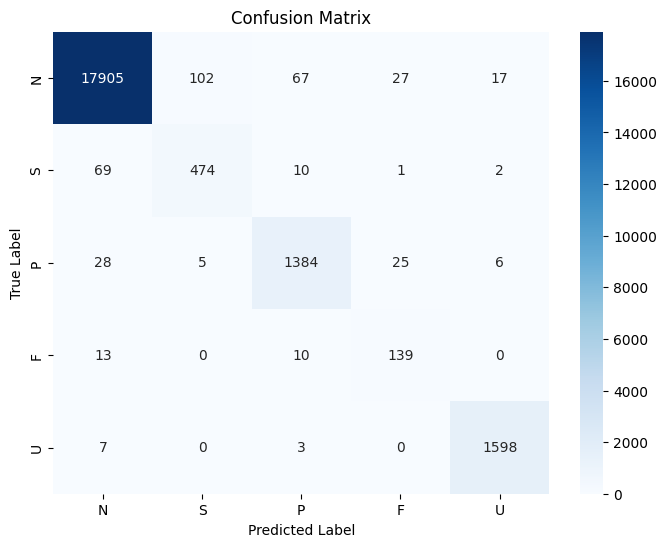

Train set Valuation
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     18118
           1       0.82      0.85      0.83       556
           2       0.94      0.96      0.95      1448
           3       0.72      0.86      0.79       162
           4       0.98      0.99      0.99      1608

    accuracy                           0.98     21892
   macro avg       0.89      0.93      0.91     21892
weighted avg       0.98      0.98      0.98     21892



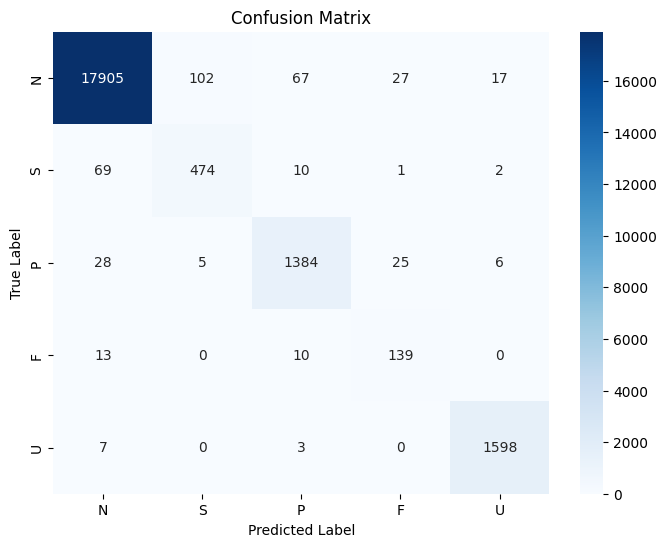

Val set Valuation
              precision    recall  f1-score   support

           0       0.99      0.99      0.99     18118
           1       0.82      0.85      0.83       556
           2       0.94      0.96      0.95      1448
           3       0.72      0.86      0.79       162
           4       0.98      0.99      0.99      1608

    accuracy                           0.98     21892
   macro avg       0.89      0.93      0.91     21892
weighted avg       0.98      0.98      0.98     21892



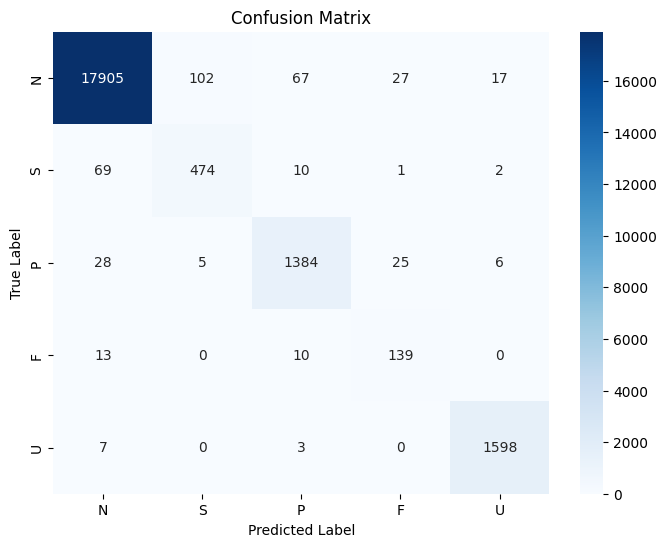

{'0': {'precision': 0.9935079347464211,
  'recall': 0.9882437355116459,
  'f1-score': 0.990868843386829,
  'support': 18118.0},
 '1': {'precision': 0.8158347676419966,
  'recall': 0.8525179856115108,
  'f1-score': 0.8337730870712401,
  'support': 556.0},
 '2': {'precision': 0.9389416553595658,
  'recall': 0.9558011049723757,
  'f1-score': 0.947296372347707,
  'support': 1448.0},
 '3': {'precision': 0.7239583333333334,
  'recall': 0.8580246913580247,
  'f1-score': 0.7853107344632768,
  'support': 162.0},
 '4': {'precision': 0.984596426370918,
  'recall': 0.9937810945273632,
  'f1-score': 0.9891674404209223,
  'support': 1608.0},
 'accuracy': 0.982093915585602,
 'macro avg': {'precision': 0.891367823490447,
  'recall': 0.9296737223961842,
  'f1-score': 0.909283295537995,
  'support': 21892.0},
 'weighted avg': {'precision': 0.9827371054773294,
  'recall': 0.982093915585602,
  'f1-score': 0.9823509168295975,
  'support': 21892.0}}

In [10]:
predict_outcome = {0. : 'N', 1. : 'S', 2. : 'P', 3. : 'F', 4. : 'U'}
labels = [predict_outcome[i] for i in range(5)]
##Test set
# Evaluation
performance_evaluation(model, test_loader, labels, "Test set Valuation")

##Train set
# Evaluation
performance_evaluation(model, train_loader, labels, "Train set Valuation")

##Val set
# Evaluation
performance_evaluation(model, val_loader, labels, "Val set Valuation")

In [11]:
path = "models_save/"
model_save = path + "CNN_Resnet.pth"
#Save Trained Model:
torch.save(model.state_dict(), model_save)
print("Model saved successfully.")

Model saved successfully.
